# **Applied Machine Learning Lab-(MCSE630P)**

# **Assignment-10 (ADABOOST)**

**Name:** Shrihariharan S [24MCS1058]

* we used kaggle dataset: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data
* Used the data set utilized for classification and apply Adaboost algorithm to

*   List item
*   List item

compare and infer the performances of the boosting classifier over single classifier.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split

In [7]:
df=pd.read_csv('/content/loan_data.csv')

In [8]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [10]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [11]:
df.shape

(45000, 14)

In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [13]:
X=df.drop('loan_status',axis=1)
y=df['loan_status']

In [14]:
# Identify numerical columns
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identify categorical columns
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

# Display the results
print("Numerical Columns:", numerical_columns)
print("Categorical Columns:", categorical_columns)

Numerical Columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Categorical Columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


In [15]:
# Define transformers for numerical and categorical columns
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both pipelines into a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_columns),
        ('cat', categorical_pipeline, categorical_columns)
    ]
)

# Fit and transform the data
X_transformed = preprocessor.fit_transform(X)

print("Transformed data shape:", X_transformed.shape)

Transformed data shape: (45000, 27)


In [16]:
X_transformed

array([[-0.95353824, -0.10408961, -0.89228413, ...,  0.        ,
         1.        ,  0.        ],
       [-1.11896309, -0.84600467, -0.89228413, ...,  0.        ,
         0.        ,  1.        ],
       [-0.45726369, -0.84406489, -0.3975175 , ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.8661351 , -0.29068126,  0.26217134, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.2044357 , -0.58634807, -0.23259529, ...,  0.        ,
         1.        ,  0.        ],
       [-0.62268854, -0.35699428, -0.72736192, ...,  0.        ,
         1.        ,  0.        ]])

In [17]:
X_transformed.shape

(45000, 27)

In [18]:
y.shape

(45000,)

In [19]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.3) # 70% training and 30% test

In [20]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((31500, 27), (13500, 27), (31500,), (13500,))

In [21]:
# Create adaboost classifer object
adaboost = AdaBoostClassifier(n_estimators=50,
                         learning_rate=1)
# Train Adaboost Classifer
model = adaboost.fit(X_train, y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [22]:

#Predict the response for test dataset
y_pred = model.predict(X_test)

In [23]:
from sklearn import metrics

In [24]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9121481481481482


In [25]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[9942  483]
 [ 703 2372]]


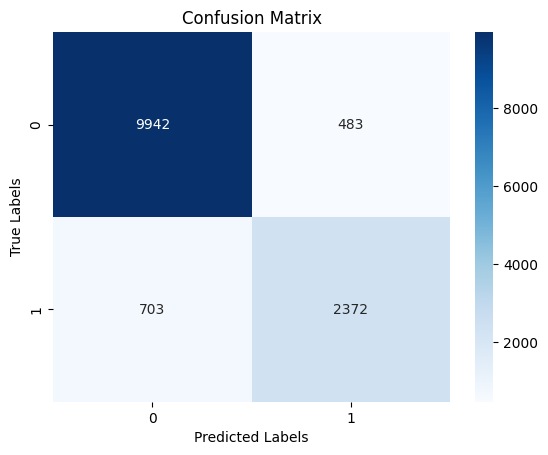

In [26]:
heatmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
heatmap.set_title("Confusion Matrix")
heatmap.set_xlabel("Predicted Labels")
heatmap.set_ylabel("True Labels")
plt.show()

# **ADDITIONAL LEARNING:**



# **LOGISTIC REGRESSION**




In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
log=LogisticRegression()

In [29]:
# Create adaboost classifer object
abc= AdaBoostClassifier(n_estimators=50, estimator=log,learning_rate=1)

In [30]:
model1 = abc.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [32]:
y_pred1 = model1.predict(X_test)

In [34]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred1))

Accuracy: 0.8937037037037037


In [37]:
confusion_matrix1 = metrics.confusion_matrix(y_test, y_pred1)
print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[9814  611]
 [ 824 2251]]


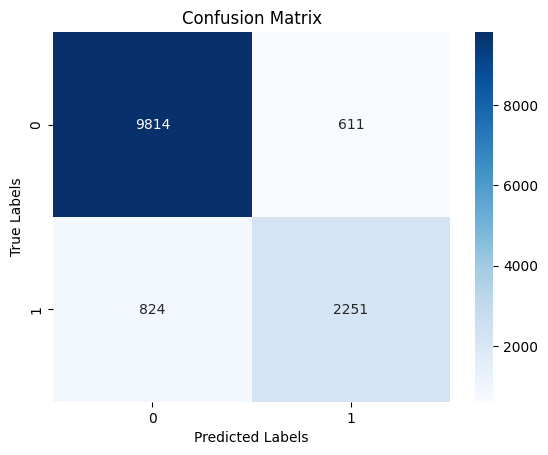

In [38]:
heatmap = sns.heatmap(confusion_matrix1, annot=True, fmt="d", cmap="Blues")
heatmap.set_title("Confusion Matrix")
heatmap.set_xlabel("Predicted Labels")
heatmap.set_ylabel("True Labels")
plt.show()

# **DECISION TREE CLASSIFIER**




In [39]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()

In [40]:
abc= AdaBoostClassifier(n_estimators=50, estimator=clf,learning_rate=1)

In [42]:
model2 = abc.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [43]:
y_pred2 = model2.predict(X_test)

In [44]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred2))

Accuracy: 0.8954814814814814


# **RANDOMFOREST CLASSIFIER**




In [45]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
cl = RandomForestClassifier(n_estimators=100)

In [50]:
abc= AdaBoostClassifier(n_estimators=50, estimator=cl,learning_rate=1)

In [51]:
model3 = abc.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [54]:
y_pred3 = model3.predict(X_test)

In [55]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred3))

Accuracy: 0.9241481481481482


In [56]:
confusion_matrix1 = metrics.confusion_matrix(y_test, y_pred3)
print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[9814  611]
 [ 824 2251]]


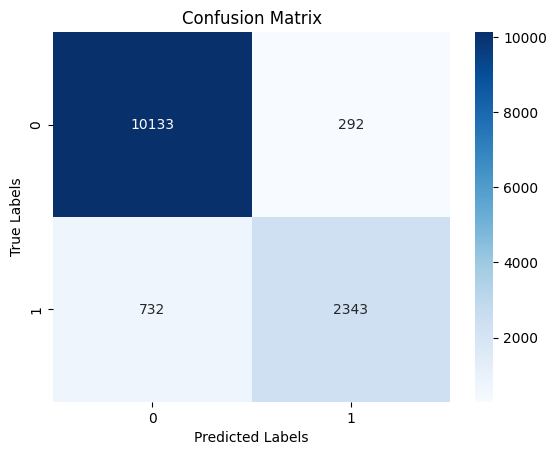

In [57]:
heatmap = sns.heatmap(confusion_matrix1, annot=True, fmt="d", cmap="Blues")
heatmap.set_title("Confusion Matrix")
heatmap.set_xlabel("Predicted Labels")
heatmap.set_ylabel("True Labels")
plt.show()

**OBSERVATION:**


*   We have developed various models and added as the estimator for the adaboost and compared the results
*  Based on our observation we could see that:
               
1.  Adaboost (with default estimator) provides accuracy of 91.21481481481482%
2.  Adaboost (with LOGISTIC REGRESSION as estimator)  provides accuracy of 89.37037037037037%
3. Adaboost (with DECISION TREE CLASSIFIER as estimator)  provides accuracy of 89.54814814814814%
4. Adaboost (with RANDOMFOREST CLASSIFIER as estimator)  provides accuracy of 0.92.41481481481482%


*   Based on the above observation we could see that the randomForest performs well with the highest accuracy of 92.41481481481482 %






